In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('Dados-modelo/df_preliminar.csv', sep=';')

In [18]:
display(
    df.info(),
    df.describe(),
    df.isna().sum()
    )

<class 'pandas.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       645 non-null    int64  
 1   Unnamed: 0         645 non-null    int64  
 2   ACESSO_LOCAL       645 non-null    int64  
 3   MULTIPLO_PESA      645 non-null    int64  
 4   REGIAO             645 non-null    str    
 5   PESA               645 non-null    str    
 6   MUNI_REFERENCIADO  645 non-null    str    
 7   OBSERVACOES        645 non-null    str    
 8   LAT_MUNI           645 non-null    float64
 9   LON_MUNI           645 non-null    float64
 10  LAT_PESA           645 non-null    float64
 11  LON_PESA           645 non-null    float64
 12  DISTANCIA          645 non-null    float64
 13  TEMPO              645 non-null    float64
 14  IBGE               645 non-null    int64  
 15  MUNI_NOME_x        645 non-null    str    
 16  POP10              645 non-null    fl

None

,Unnamed: 0.1,Unnamed: 0,ACESSO_LOCAL,MULTIPLO_PESA,LAT_MUNI,LON_MUNI,LAT_PESA,LON_PESA,DISTANCIA,TEMPO,...,PROP_CASOS_0A10,PROP_CASOS_60MAIS,TAXA_MG_100MIL,CLASS_IG,SORO_IG,EVOL_IG,PROP_CLASS_IGN,PROP_SORO_IGN,PROP_EVOL_IGN,BAIXO_N
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,...,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.00000,645.000000,645.000000
mean,322.000000,322.000000,0.311628,0.110078,-21.187495,-46.533098,-21.182265,-46.526231,18.812158,18.910803,...,0.098969,0.162940,10.468078,4.711628,8.699225,9.941085,0.046519,0.05922,0.078638,0.181395
std,186.339743,186.339743,0.463518,0.313229,4.659167,10.066311,4.657134,10.062041,16.992579,16.190577,...,0.107360,0.107304,14.556843,14.828542,32.703250,44.402062,0.093461,0.10674,0.129330,0.385644
min,0.000000,0.000000,0.000000,0.000000,-25.010461,-53.054797,-25.011672,-52.949023,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,161.000000,161.000000,0.000000,0.000000,-23.006662,-49.998726,-22.983918,-49.978739,0.000000,0.000000,...,0.047600,0.101400,1.130000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,322.000000,322.000000,0.000000,0.000000,-22.115854,-48.480188,-22.195130,-48.496295,18.100000,19.500000,...,0.081600,0.166700,5.500000,1.000000,1.000000,2.000000,0.010200,0.01190,0.025600,0.000000
75%,483.000000,483.000000,1.000000,0.000000,-21.096962,-47.153221,-21.061391,-47.175715,30.000000,29.000000,...,0.119000,0.216900,14.760000,4.000000,5.000000,6.000000,0.048000,0.06900,0.100000,0.000000
max,644.000000,644.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,84.400000,70.800000,...,1.000000,1.000000,128.720000,263.000000,463.000000,864.000000,1.000000,0.66670,0.763900,1.000000


Unnamed: 0.1      0
Unnamed: 0        0
ACESSO_LOCAL      0
MULTIPLO_PESA     0
REGIAO            0
                 ..
EVOL_IG           0
PROP_CLASS_IGN    0
PROP_SORO_IGN     0
PROP_EVOL_IGN     0
BAIXO_N           0
Length: 62, dtype: int64

In [19]:
# Correlacao 1
cols = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_POP_0A10',
    'PROP_POP_60MAIS'
]

df[cols].corr().round(2)

,TEMPO,DISTANCIA,INCID_MEDIA_GERAL,PROP_MG,PROP_POP_0A10,PROP_POP_60MAIS
TEMPO,1.00,0.98,0.08,-0.06,-0.04,0.15
DISTANCIA,0.98,1.00,0.09,-0.08,-0.05,0.16
INCID_MEDIA_GERAL,0.08,0.09,1.00,-0.23,-0.32,0.34
PROP_MG,-0.06,-0.08,-0.23,1.00,0.18,-0.14
PROP_POP_0A10,-0.04,-0.05,-0.32,0.18,1.00,-0.69
PROP_POP_60MAIS,0.15,0.16,0.34,-0.14,-0.69,1.00


In [20]:
# Listar extremos

display(
df.nlargest(20, 'PROP_MG')['MUNI_REFERENCIADO'],

df.nlargest(20, 'TEMPO')['MUNI_REFERENCIADO'],

df.nlargest(20, 'INCID_MEDIA_GERAL')['MUNI_REFERENCIADO']
)

164               NOVA CAMPINA
165                    RIBEIRA
398    SANTO ANTONIO DO PINHAL
535                JACUPIRANGA
540                SETE BARRAS
592                      APIAI
549                   BERTIOGA
556                     SANTOS
294                    SERRANA
112                 ITAPORANGA
121                     TAGUAI
584                   ANGATUBA
66                     GUARACI
162     BOM SUCESSO DE ITARARE
292                  SAO SIMAO
299        RIO GRANDE DA SERRA
306               DIVINOLANDIA
543                     CAJURU
586               ITAPETININGA
555               PRAIA GRANDE
Name: MUNI_REFERENCIADO, dtype: str

141                  PIRACAIA
392       NATIVIDADE DA SERRA
117                 PORANGABA
429                 UBIRAJARA
328                    IRAPUA
162    BOM SUCESSO DE ITARARE
165                   RIBEIRA
123            TORRE DE PEDRA
344            PAULO DE FARIA
67                  JABORANDI
63                    TIMBURI
326            GASTAO VIDIGAL
101                       URU
421                  GUARANTA
330                  MACAUBAL
103                   ANHEMBI
31                    DOURADO
166                  RIVERSUL
415     CAMPOS NOVOS PAULISTA
417                    FERNAO
Name: MUNI_REFERENCIADO, dtype: str

174                  INDIAPORA
15            MURUTINGA DO SUL
246       SANTA MARIA DA SERRA
447                   GUARACAI
270              MONTE CASTELO
632              MIRASSOLANDIA
641                 ONDA VERDE
315           ALVARES FLORENCE
179               MIRA ESTRELA
582                   OUROESTE
340                  PALESTINA
2                      BARBOSA
520    MIRANTE DO PARANAPANEMA
450               MIRANDOPOLIS
273                  PAULICEIA
343                     PARISI
183               PEDRANOPOLIS
271          NOVA GUATAPORANGA
17          NOVA INDEPENDENCIA
633                POTIRENDABA
Name: MUNI_REFERENCIADO, dtype: str

In [21]:
# Correlação 2
cols = [
    'TEMPO',
    'DISTANCIA',
    'INCID_MEDIA_GERAL',
    'PROP_MG',
    'PROP_CASOS_0A10',
    'PROP_CASOS_60MAIS'
]

df[cols].corr().round(2)

,TEMPO,DISTANCIA,INCID_MEDIA_GERAL,PROP_MG,PROP_CASOS_0A10,PROP_CASOS_60MAIS
TEMPO,1.00,0.98,0.08,-0.06,0.04,0.04
DISTANCIA,0.98,1.00,0.09,-0.08,0.05,0.05
INCID_MEDIA_GERAL,0.08,0.09,1.00,-0.23,-0.09,0.32
PROP_MG,-0.06,-0.08,-0.23,1.00,0.20,-0.05
PROP_CASOS_0A10,0.04,0.05,-0.09,0.20,1.00,-0.18
PROP_CASOS_60MAIS,0.04,0.05,0.32,-0.05,-0.18,1.00


In [22]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ACESSO_LOCAL', 'MULTIPLO_PESA', 'REGIAO',
       'PESA', 'MUNI_REFERENCIADO', 'OBSERVACOES', 'LAT_MUNI', 'LON_MUNI',
       'LAT_PESA', 'LON_PESA', 'DISTANCIA', 'TEMPO', 'IBGE', 'MUNI_NOME_x',
       'POP10', 'POP12', 'POP11A59', 'POP60', 'POP_GERAL', 'MACRO_CODIGO',
       'MACRO_NOME', 'DRS_CODIGO', 'DRS_NOME', 'CIR_CODIGO', 'CIR_NOME',
       'TOTAL_CASOS', 'TOTAL_10A', 'TOTAL_12A', 'TOTAL_11A59', 'TOTAL_60',
       'LEVE', 'MG', 'MG_ORIGINAL', 'LEVE_10', 'MG_10', 'LEVE_12', 'MG_12',
       'LEVE_11A59', 'MG_11A59', 'LEVE_60', 'MG_60', 'TOTAL_AMPOLAS',
       'CAT_TEMPO', 'PROP_POP_0A10', 'PROP_POP_60MAIS', 'LOG_POP', 'PROP_MG',
       'INCID_MEDIA_GERAL', 'INCID_0A10', 'INCID_60MAIS', 'PROP_CASOS_0A10',
       'PROP_CASOS_60MAIS', 'TAXA_MG_100MIL', 'CLASS_IG', 'SORO_IG', 'EVOL_IG',
       'PROP_CLASS_IGN', 'PROP_SORO_IGN', 'PROP_EVOL_IGN', 'BAIXO_N'],
      dtype='str')

In [23]:
df['MG'].sum()

np.int64(7652)

In [24]:
df['MG_ORIGINAL'].sum()

np.int64(5398)

In [27]:
dd = df[df['PROP_MG'] > 0]

In [51]:
dd['PROP_MG'].describe()

count    543.000000
mean       0.121142
std        0.142929
min        0.010000
25%        0.050000
50%        0.080000
75%        0.140000
max        1.000000
Name: PROP_MG, dtype: float64

<Axes: xlabel='CAT_TEMPO', ylabel='PROP_MG'>

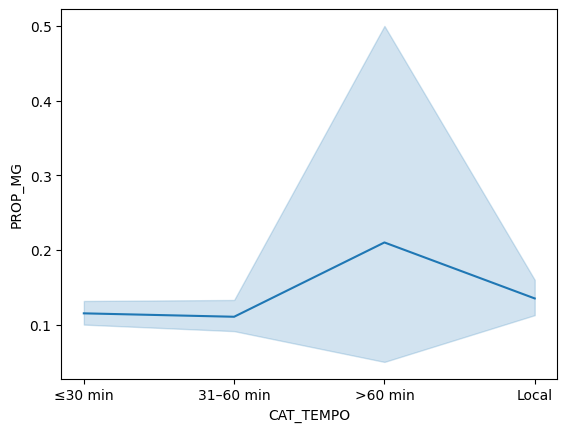

In [44]:
plt.clf()
sns.lineplot(x = 'CAT_TEMPO', y='PROP_MG', data=dd)

<Figure size 640x480 with 0 Axes>

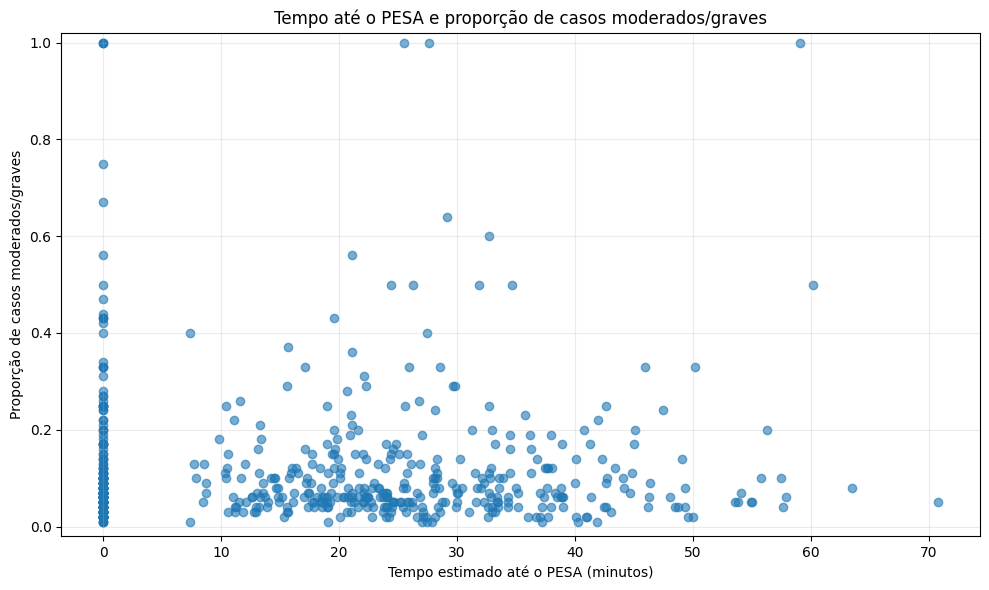

In [43]:
plt.clf()
plt.figure(figsize=(10, 6))

plt.scatter(
    dd["TEMPO"],
    dd["PROP_MG"],
    alpha=0.6
)

plt.xlabel("Tempo estimado até o PESA (minutos)")
plt.ylabel("Proporção de casos moderados/graves")
plt.title("Tempo até o PESA e proporção de casos moderados/graves")

plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()